# Speech command robustness: data to paired baseline

This notebook builds an auditable, small local example of a clean-versus-acoustic-shift evaluation. Synthetic records and predictions make every local section deterministic; they are not Speech Commands measurements. Actual source data preparation, feature caching, model fitting, and held-out bootstrap analysis are clearly marked `offloaded` and are not run by the local walkthrough.

## Public data and license card

Planned source: Google Speech Commands v0.02, distributed through the [TensorFlow Datasets catalog](https://www.tensorflow.org/datasets/catalog/speech_commands), 16 kHz one-second word clips. The dataset is released under [Creative Commons Attribution 4.0](https://creativecommons.org/licenses/by/4.0/); cite Warden (2018), *Speech Commands: A Dataset for Limited-Vocabulary Speech Recognition*, [arXiv:1804.03209](https://arxiv.org/abs/1804.03209). Check the downloaded archive and its current dataset card before redistribution. This notebook does not download or bundle audio.

The compact target vocabulary is yes/no/up/down/left/right/on/off/stop/go plus `unknown` and `silence`; source assignment and exact inclusion rules belong in the produced manifest.

## Split and leakage policy

Use a seeded, label-stratified 70/15/15 sample split for train, calibration, and test. Calibration data chooses temperature and thresholds; test data is used once for reporting. This split is at the sample level, so speakers may overlap across partitions. It does not estimate speaker-disjoint generalization. Duplicate content checksums are audited before splitting.


In [1]:
from collections import Counter
import hashlib
import numpy as np
import matplotlib.pyplot as plt

from src.audio import add_white_noise, apply_gain, apply_reverb
from src.data import ManifestRecord, stratified_split
from src.experiment import ExperimentConfig, evaluate_predictions

SEED = 17
LABELS = ('yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'unknown', 'silence')
rng = np.random.default_rng(SEED)
records = [ManifestRecord(f'synth-{label}-{i:03d}', label, f'synthetic://{label}/{i:03d}')
           for label in LABELS for i in range(20)]
checksums = {row.identifier: hashlib.sha256(row.identifier.encode()).hexdigest() for row in records}
split = stratified_split(records, seed=SEED)
print(f'Local fallback: {len(records)} deterministic synthetic records across {len(LABELS)} labels; no source audio loaded.')

Local fallback: 240 deterministic synthetic records across 12 labels; no source audio loaded.


## Split, quality control, and cache policy

The local fallback exercises partition bookkeeping only. In the source-data run, cap each target label at 600 examples, construct `unknown` from non-target words and `silence` from fixed background windows, normalize clips to one second at 16 kHz, and record source checksums before any derived representation is cached. Cache identity must bind identifier, source checksum, and transform configuration. Cache writes and verification against actual audio are offloaded below.

Sample-level splitting permits speaker overlap. Hash duplicates are checked before the split, and no calibration/test item is used for fitting.


In [2]:
allowed = set(LABELS)
assert len({row.identifier for row in records}) == len(records)
assert all(row.label in allowed for row in records)
assert set().union(*(set(row.identifier for row in split[name]) for name in split)) == {row.identifier for row in records}
assert sum(len(rows) for rows in split.values()) == len(records)
split_counts = {name: len(rows) for name, rows in split.items()}
label_counts = Counter(row.label for row in records)
duplicate_count = len(records) - len(set(checksums.values()))
sample_rates = np.full(len(records), 16_000)
clip_seconds = np.ones(len(records), dtype=float)
print(f'QC passed: {len(allowed)} allowed labels; partitions={split_counts}; duplicate identifiers={duplicate_count}; speaker-disjoint guarantee=False.')

QC passed: 12 allowed labels; partitions={'train': 168, 'calibration': 36, 'test': 36}; duplicate identifiers=0; speaker-disjoint guarantee=False.


### How to read the population audit

The left panel checks label balance; the center and right panels check the declared sample-rate and duration assumptions. The checksum total is printed above the figure. Synthetic counts validate the plotting path only: a real manifest should show source-derived counts and checksums.

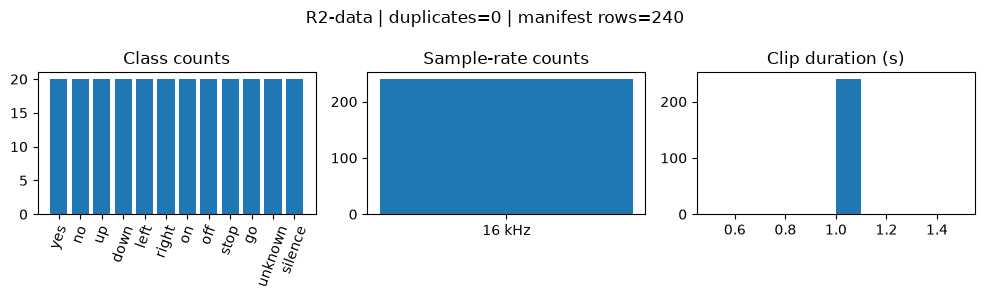

In [3]:
assert len(label_counts) == 12 and set(sample_rates) == {16_000}
assert np.allclose(clip_seconds, 1.0)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].bar(list(label_counts), list(label_counts.values())); axes[0].tick_params(axis='x', rotation=70); axes[0].set_title('Class counts')
axes[1].bar(['16 kHz'], [len(sample_rates)]); axes[1].set_title('Sample-rate counts')
axes[2].hist(clip_seconds, bins=np.linspace(.5, 1.5, 11)); axes[2].set_title('Clip duration (s)')
fig.suptitle(f'R2-data | duplicates={duplicate_count} | manifest rows={len(records)}'); fig.tight_layout(); plt.show()

In [ ]:
# OFFLOADED: use the actual Speech Commands archive.
# 1) Build/check the capped manifest and source checksums.
# 2) Materialize the log-mel feature cache with CacheStore, keyed by
#    identifier + source checksum + transform parameters.
# 3) Record the archive version, manifest digest, cache digest, machine,
#    and executed output cells alongside the resulting artifact.
# This cell is intentionally not executed locally.

## Stress construction and measured severity

The local example applies deterministic white noise, gain, and synthetic decay reverb to generated waveforms. Requested and measured SNR are paired per example. Real Speech Commands transformations used for training and evaluation are offloaded; requested severity alone must never be reported as achieved severity.

In [4]:
requested_snr_db = np.array([5., 7., 9., 11., 13., 15., 17., 20.])
achieved_snr_db = []
gain_db = np.linspace(-3, 3, requested_snr_db.size)
reverb_decay_seconds = np.linspace(.08, .20, requested_snr_db.size)
base_wave = .15 * np.sin(2 * np.pi * 330 * np.arange(16_000) / 16_000)
for i, target_snr in enumerate(requested_snr_db):
    shifted, _ = add_white_noise(base_wave, sample_rate=16_000, snr_db=float(target_snr), seed=SEED + i)
    signal_rms = np.sqrt(np.mean(base_wave.astype(float) ** 2))
    noise_rms = np.sqrt(np.mean((shifted - base_wave).astype(float) ** 2))
    achieved_snr_db.append(20 * np.log10(signal_rms / noise_rms))
    shifted, _ = apply_gain(shifted, gain_db=float(gain_db[i]))
    shifted, _ = apply_reverb(shifted, sample_rate=16_000, decay_seconds=float(reverb_decay_seconds[i]))
achieved_snr_db = np.asarray(achieved_snr_db)
assert achieved_snr_db.shape == requested_snr_db.shape and np.isfinite(achieved_snr_db).all()
assert np.max(np.abs(achieved_snr_db - requested_snr_db)) < .1
print(f'Stress self-check passed: {len(achieved_snr_db)} paired, finite examples; max |requested − measured SNR|={np.max(np.abs(achieved_snr_db-requested_snr_db)):.2f} dB.')

Stress self-check passed: 8 paired, finite examples; max |requested − measured SNR|=0.07 dB.


### How to read requested versus achieved severity

Each marker is one synthetic waveform. The diagonal is perfect SNR realization; deviations reveal transform or measurement error. Gain and reverb are shown as paired records in the title metadata rather than treated as interchangeable with SNR.

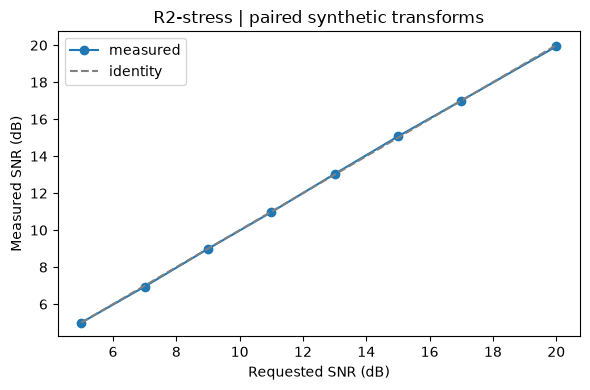

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(requested_snr_db, achieved_snr_db, 'o-', label='measured')
ax.plot([5, 20], [5, 20], '--', color='gray', label='identity')
ax.set(xlabel='Requested SNR (dB)', ylabel='Measured SNR (dB)', title='R2-stress | paired synthetic transforms'); ax.legend(); fig.tight_layout(); plt.show()

In [ ]:
# OFFLOADED: fit the CNN conditions on the training partition only.
# Conditions: clean, train-time spectrogram masking, train-time acoustic
# augmentation. Hold split/seed/microbatch=64/accumulation=2/AdamW/
# max_epochs=6/patience=2 fixed. Separately compare frozen Wav2Vec2
# plus linear head and final-block adaptation for clean/acoustic only.
# Record parameters, wall time, peak memory, and stop cause.
# The 300 s T4 calibration observed 296130 steps and 40.1 MiB peak;
# these are measurements, not a throughput-to-cost conversion.
# Do not substitute another encoder when pretrained weights are absent.

## Model and paired evaluation

The planned CNN consumes log-mel features. Conditions use a shared seed, epoch ceiling, patience, microbatch, accumulation schedule, and AdamW settings. Calibration data is reserved for temperature fitting and threshold selection. The deterministic fallback below creates paired class probabilities to exercise metric reporting; it is not a trained classifier or a benchmark result. The actual held-out bootstrap is tagged `offloaded`.


In [6]:
configs = {name: ExperimentConfig(condition=name, seed=SEED, max_epochs=6, patience=2, microbatch_size=64, accumulation_steps=2)
           for name in ('clean', 'masking', 'acoustic')}
assert len({config.optimization_budget for config in configs.values()}) == 1
print('Fair-budget check:', {key: value.optimization_budget for key, value in configs.items()})
n, class_count = 96, 4
y = np.tile(np.arange(class_count), n // class_count)
clean_logits = rng.normal(0, .45, (n, class_count)); clean_logits[np.arange(n), y] += 1.6
shift_logits = clean_logits.copy(); shift_logits[rng.choice(n, 24, replace=False)] *= .45
clean_probs = np.exp(clean_logits - clean_logits.max(axis=1, keepdims=True)); clean_probs /= clean_probs.sum(axis=1, keepdims=True)
shift_probs = np.exp(shift_logits - shift_logits.max(axis=1, keepdims=True)); shift_probs /= shift_probs.sum(axis=1, keepdims=True)
paired = evaluate_predictions(tuple(f'synthetic-test-{i:03d}' for i in range(n)), y, clean_probs, shift_probs, bootstrap_seed=SEED, bootstrap_resamples=100)
assert paired.identifiers[0] == 'synthetic-test-000' and len(paired.identifiers) == n
assert paired.clean.accuracy_interval.point == paired.clean.accuracy
print(f'Paired fallback self-check: n={n}; clean acc={paired.clean.accuracy:.3f}; shifted acc={paired.shifted.accuracy:.3f}; Δ={paired.accuracy_change:+.3f}; clean macro-F1 95% bootstrap=[{paired.clean.macro_f1_interval.lower:.3f}, {paired.clean.macro_f1_interval.upper:.3f}].')

Fair-budget check: {'clean': (17, 6, 64, 2), 'masking': (17, 6, 64, 2), 'acoustic': (17, 6, 64, 2)}
Paired fallback self-check: n=96; clean acc=0.979; shifted acc=0.979; Δ=+0.000; clean macro-F1 95% bootstrap=[0.946, 1.000].


### How to read the paired baseline summary

The left panel compares point metrics and their row-bootstrap intervals for clean and shifted synthetic predictions. The right panel orders examples by confidence; lower risk at the same coverage is preferable. Intervals are unpaired here for readability, while the shared identifiers preserve row alignment. These illustrative draws must not be cited as model performance.

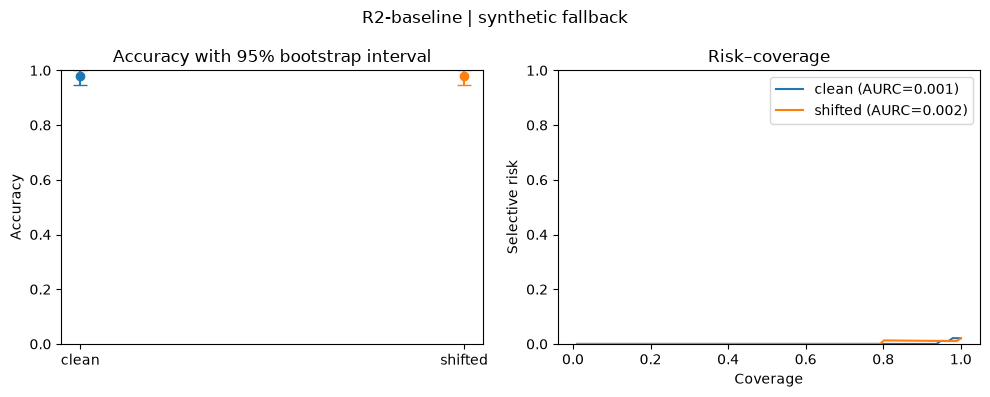

In [7]:
assert paired.clean.accuracy_interval.lower <= paired.clean.accuracy <= paired.clean.accuracy_interval.upper
assert paired.shifted.accuracy_interval.lower <= paired.shifted.accuracy <= paired.shifted.accuracy_interval.upper
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for x, name, metric in ((0, 'clean', paired.clean), (1, 'shifted', paired.shifted)):
    axes[0].errorbar(x, metric.accuracy, yerr=[[metric.accuracy-metric.accuracy_interval.lower], [metric.accuracy_interval.upper-metric.accuracy]], fmt='o', capsize=5, label=name)
axes[0].set(xticks=[0, 1], xticklabels=['clean', 'shifted'], ylabel='Accuracy', ylim=(0, 1), title='Accuracy with 95% bootstrap interval')
for name, metric in (('clean', paired.clean), ('shifted', paired.shifted)):
    coverage, risk = metric.risk_coverage; axes[1].plot(coverage, risk, label=f'{name} (AURC={metric.aurc:.3f})')
axes[1].set(xlabel='Coverage', ylabel='Selective risk', ylim=(0, 1), title='Risk–coverage'); axes[1].legend()
fig.suptitle('R2-baseline | synthetic fallback'); fig.tight_layout(); plt.show()

In [ ]:
# OFFLOADED: evaluate each retained model on the same held-out identifiers
# and labels under clean and shifted audio. Save probability matrices and
# provenance, then bootstrap paired row indices for metric differences.
# Report per-class recall, macro-F1, NLL, Brier, ECE at 10/15/20 bins,
# risk-coverage/AURC, calibration thresholds, and resource records.
# A shifted-test threshold is a measurement, not a shift-valid guarantee.
# Include run id, source/split/model hashes, seed, and bootstrap count.

## Interpretation and limits

This executable pass proves that split bookkeeping, deterministic corruption measurement, paired metric summaries, and plots can run locally. It establishes no acoustic robustness gain. A real run must preserve exact clean/shifted row pairing, report resource measurements, fit only on train, calibrate only on calibration, and disclose sample-level speaker leakage. If pretrained weights or the execution budget are unavailable, report that transfer comparison as unavailable rather than substituting a different model.